In [1]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

In [5]:
# # load in all corr means and all corr standard deviations
# with open("results/all_corr_means.pkl", 'rb') as f:
#     corr_means = pickle.load(f)
    
# with open("results/all_corr_standard_deviations.pkl", 'rb') as f:
#     corr_stds = pickle.load(f)

with open("results/voxelwise_stats.pkl", 'rb') as f:
        vxl_stats = pickle.load(f)
    
demo_data = pd.read_csv("/home/zachkaras/fmri/fmri_model/master-survey-data.csv")

def nested_dict():
        return defaultdict(nested_dict)

In [7]:
vxl_stats

{'111': {'code': {'deepseek_6b': {'layer_16': {'correlation_mean': 0.15907258484802422,
     'correlation_std': 0.27956066815300734},
    'layer_24': {'correlation_mean': 0.17340466728287748,
     'correlation_std': 0.2870187665618364},
    'layer_0': {'correlation_mean': 0.166193731712073,
     'correlation_std': 0.27808152162128535},
    'layer_32': {'correlation_mean': 0.154097291472855,
     'correlation_std': 0.27529469085457103},
    'layer_8': {'correlation_mean': 0.1579115366707556,
     'correlation_std': 0.27595400562258027}},
   'starcoder2_3b': {'layer_0': {'correlation_mean': 0.19921988101657404,
     'correlation_std': 0.29693170005587416},
    'layer_14': {'correlation_mean': 0.20505116128908063,
     'correlation_std': 0.3015981994718247},
    'layer_28': {'correlation_mean': 0.2027292700552276,
     'correlation_std': 0.32537461368650517},
    'layer_21': {'correlation_mean': 0.2057045094470103,
     'correlation_std': 0.3078361363333346},
    'layer_7': {'correlation_

In [ ]:
# TODO - look for voxels with the narrowest range of correlation values among participants
# TODO - look at brain plots to find voxels with highest correlation values
# TODO - features from code (navigation, planning, loop, conditional, variable declaration, data (structure) manipulation)
# TODO - representation similarity analysis between participants
# TODO - maybe swap directionality of the ridge regression to get neural network embeddings from brain activity
# TODO - out of distribution test for new stimuli - training and testing on perturbed stimuli

In [4]:
# Filtering top 10K voxels - 
# save in same dictionary format of person, task, model, layer
participant_path = "/storage1/fmri_model_data/ridge_regression_models"
participants = os.listdir(participant_path)

top_means = nested_dict()
top_stds  = nested_dict()

for person in participants:
    print(person)
    person_path = f"{participant_path}/{person}"
    correlations = [f for f in os.listdir(person_path) if f.endswith('.pkl')]
    
    for pkl in correlations:
        meta_data = pkl.split('-')
        model = meta_data[0]
        layer = meta_data[1]
        task = meta_data[2]
        
        pickle_path = f"{person_path}/{pkl}"
        with open(pickle_path, 'rb') as f:
            corr_values = list(pickle.load(f))
        corr_values.sort()
        top_corrs = corr_values[-10**4:]
        top_mean = np.mean(top_corrs)
        top_std  = np.std(top_corrs)
        
        top_means[person][task][model][layer] = top_mean
        top_stds[person][task][model][layer] = top_std
    #     break
    # break

111
121
150
112
101
130
203
125
204
117
134
201
122
151
108
133
129
105
118
109
144
119
141
138
142


In [9]:
# dictionary structure is participant, task, model, layer

# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
participant_performance = defaultdict(list)

# RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
layer_performance = nested_dict()

# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
model_performance = defaultdict(list)

# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
task_performance = defaultdict(list)

for person, taskModelLayerCorrStat in vxl_stats.items():
    for task, modelLayerCorrStat in taskModelLayerCorrStat.items():
        # if task == 'prose':
        #     continue
        for model,layerCorrStat in modelLayerCorrStat.items():
            for layer,corrStat in layerCorrStat.items():
                val = top_means[person][task][model][layer]
                # val = top_stds[person][task][model][layer]
                # val = corr_means[person][task][model][layer]
                # val = corr_stds[person][task][model][layer]
                
                participant_performance[person].append(val)    
                model_performance[model].append(val)
                task_performance[task].append(val)
                
                if layer not in layer_performance[model].keys():
                    layer_performance[model][layer] = [val]
                else:
                    layer_performance[model][layer].append(val)


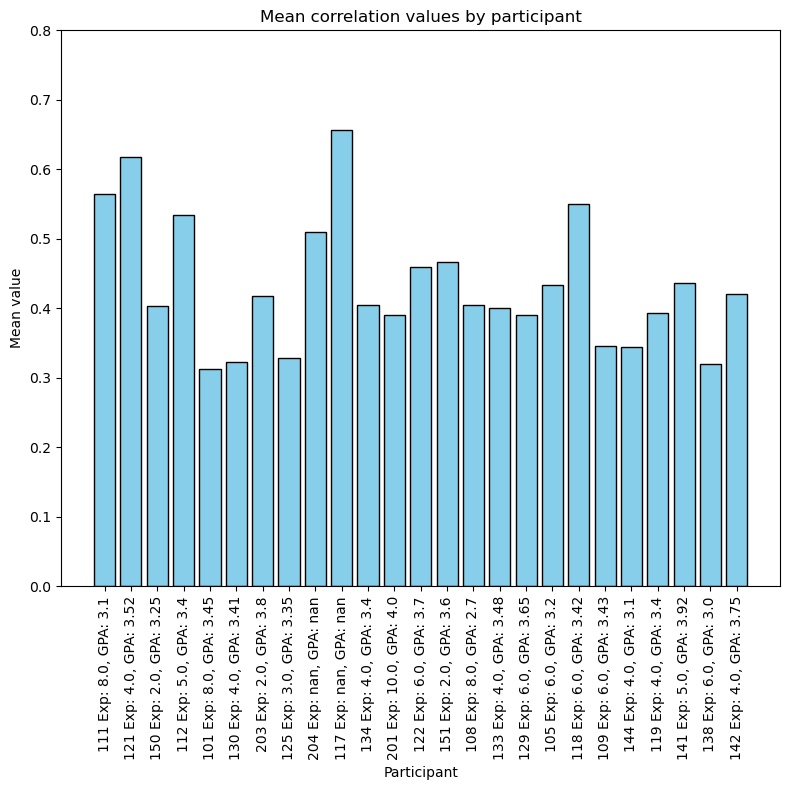

In [10]:
# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
# can use demogrpahic data for code_correct, code_complete, Code_more_structured, Typing Constraints, Code_LR_Instinct_vs_Solved
def participant_index(id):
    # idx = (np.where(demo_data['id'] == int(id)))[0]
    # print(id, idx)
    return (np.where(demo_data['id'] == int(id)))[0][0]

# Compute means
labels = list(participant_performance.keys())
# Semesters experience and GPA
labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

# code correct and code complete
# labels = [f"{l} Correct: {demo_data.loc[participant_index(l), 'code_correct']}, Complete: {demo_data.loc[participant_index(l), 'code_complete']}" for l in labels]

# code more structured, typing constraints, instinct vs solved
# labels = [f"{l} Structured: {demo_data.loc[participant_index(l), 'Code_more_structured']}, Typing Trouble: {demo_data.loc[participant_index(l), 'Typing Constraints']}, Solved {demo_data.loc[participant_index(l), 'Code_LR_Instinct_vs_Solved']}" for l in labels]

means = [np.mean(v) for v in participant_performance.values()]

# Plot
plt.figure(figsize=(8,8))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Participant")
plt.xticks(rotation=90)
plt.ylim([0.0, 0.8])
plt.title("Mean correlation values by participant")
plt.tight_layout()
plt.show()

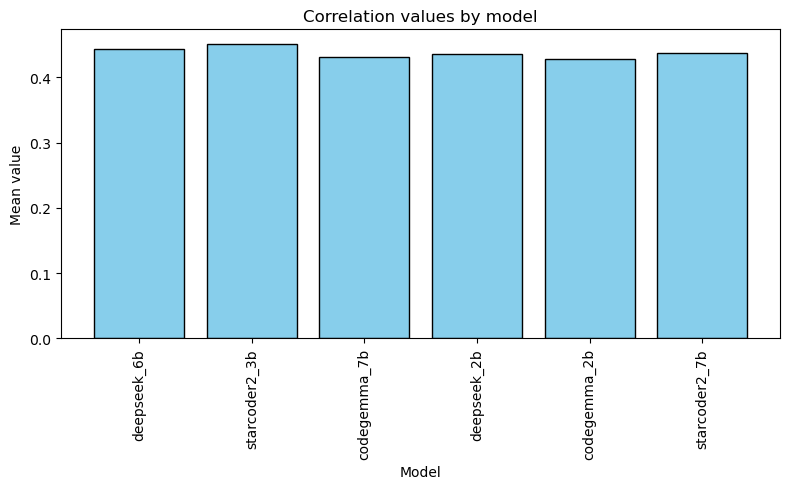

In [11]:
# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model

# Compute means
labels = list(model_performance.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in model_performance.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Model")
plt.xticks(rotation=90)
plt.title("Correlation values by model")
plt.tight_layout()
plt.show()

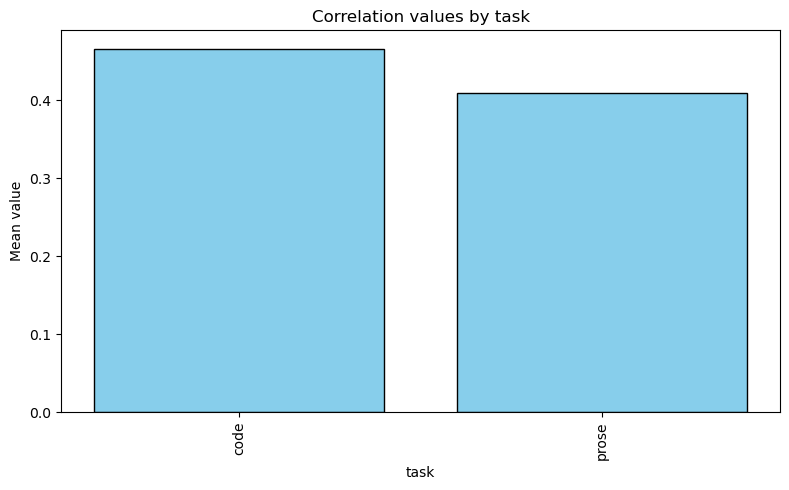

In [12]:
# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks

# Compute means
labels = list(task_performance.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in task_performance.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("task")
plt.xticks(rotation=90)
plt.title("Correlation values by task")
plt.tight_layout()
plt.show()

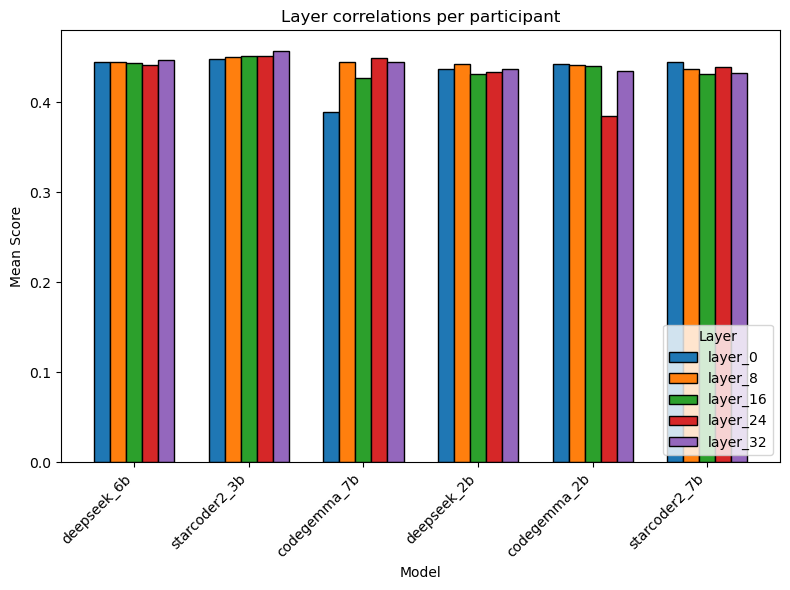

In [13]:
layer_performance = json.loads(json.dumps(layer_performance))

models = list(layer_performance.keys())
layers = list(next(iter(layer_performance.values())).keys())  # assume all participants have same tasks

layers = sorted(
    next(iter(layer_performance.values())).keys(),
    key=lambda x: int(x.split('_')[1])
)

# Compute means
# means = {p: [np.mean(data[p][t]) for t in tasks] for p in participants}
means = {}
for model, layerScores in layer_performance.items():
    for layer,scores in layerScores.items():
        if model not in means.keys():
            means[model] = [np.mean(scores)]
        else:
            # print(model, layer, scores)
            means[model].append(np.mean(scores))
            
# means = {m: [layer_performance[m][l] for l in layers] for m in models}

# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [means[m][i] for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.title("Layer correlations per participant")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Layer", loc='lower right')
plt.tight_layout()
plt.show()

### With PCA to reduce dimensionality of embeddings

In [14]:
# Filtering top 10K voxels - 
# save in same dictionary format of person, task, model, layer
participant_path = "/storage1/fmri_model_data/ridge_regression_pca_models"
participants = os.listdir(participant_path)

top_means_pca = nested_dict()
top_stds_pca  = nested_dict()

for person in participants:
    print(person)
    person_path = f"{participant_path}/{person}"
    correlations = [f for f in os.listdir(person_path) if f.endswith('.pkl')]
    
    for pkl in correlations:
        meta_data = pkl.split('-')
        model = meta_data[0]
        layer = meta_data[1]
        task = meta_data[2]
        
        pickle_path = f"{person_path}/{pkl}"
        with open(pickle_path, 'rb') as f:
            corr_values = list(pickle.load(f))
        corr_values.sort()
        top_corrs = corr_values[-10**4:]
        top_mean = np.mean(top_corrs)
        top_std  = np.std(top_corrs)
        
        top_means_pca[person][task][model][layer] = top_mean
        top_stds_pca[person][task][model][layer] = top_std

111
121
150
112
101
130
203
125
204
117
134
201
122
151
108
133
129
105
118
109
144
119
141
138
142


In [15]:
# With PCA
# dictionary structure is participant, task, model, layer

# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
participant_performance_pca = defaultdict(list)

# RQ2 - how do the model layers (early vs. late) relate to correlation? For each model, collect correlation values at each layer
layer_performance_pca = nested_dict()

# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model
model_performance_pca = defaultdict(list)

# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks
task_performance_pca = defaultdict(list)

for person, taskModelLayerCorr in vxl_stats.items():
    for task, modelLayerCorr in taskModelLayerCorr.items():
        # if task == 'prose':
        #     continue
        for model,layerCorr in modelLayerCorr.items():
            for layer,corr in layerCorr.items():
                val = top_means_pca[person][task][model][layer]
                # val = top_stds[person][task][model][layer]
                # val = corr_means[person][task][model][layer]
                # val = corr_stds[person][task][model][layer]
                
                participant_performance_pca[person].append(val)    
                model_performance_pca[model].append(val)
                task_performance_pca[task].append(val)
                
                if layer not in layer_performance_pca[model].keys():
                    layer_performance_pca[model][layer] = [val]
                else:
                    layer_performance_pca[model][layer].append(val)

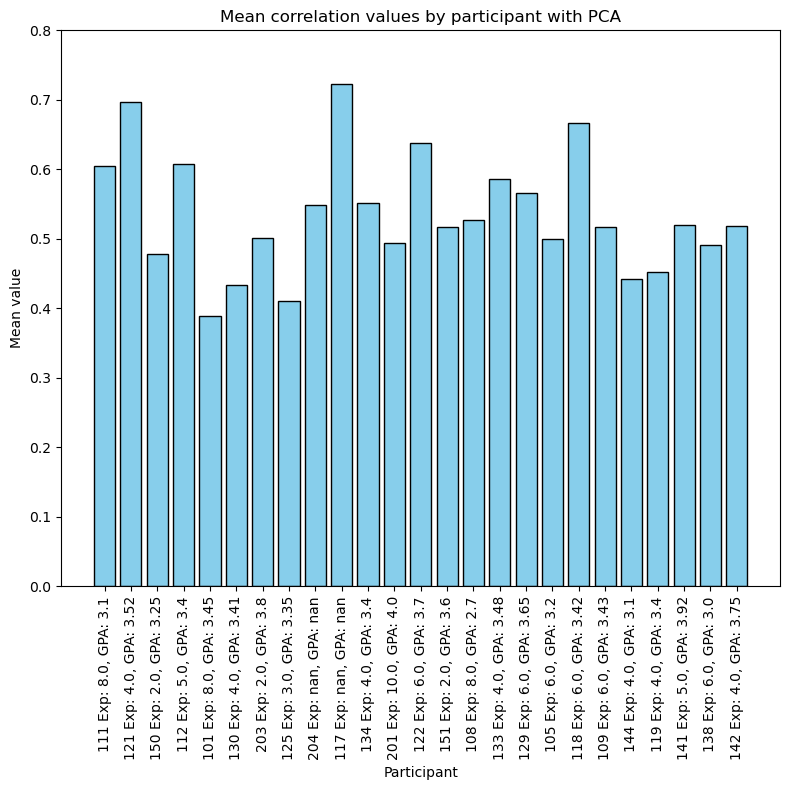

In [16]:
# RQ1 - how do correlation values relate to coding performance? Collect correlation values for each participant
# can use demogrpahic data for code_correct, code_complete, Code_more_structured, Typing Constraints, Code_LR_Instinct_vs_Solved
def participant_index(id):
    # idx = (np.where(demo_data['id'] == int(id)))[0]
    # print(id, idx)
    return (np.where(demo_data['id'] == int(id)))[0][0]

# Compute means
labels = list(participant_performance_pca.keys())
# Semesters experience and GPA
labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]

# code correct and code complete
# labels = [f"{l} Correct: {demo_data.loc[participant_index(l), 'code_correct']}, Complete: {demo_data.loc[participant_index(l), 'code_complete']}" for l in labels]

# code more structured, typing constraints, instinct vs solved
# labels = [f"{l} Structured: {demo_data.loc[participant_index(l), 'Code_more_structured']}, Typing Trouble: {demo_data.loc[participant_index(l), 'Typing Constraints']}, Solved {demo_data.loc[participant_index(l), 'Code_LR_Instinct_vs_Solved']}" for l in labels]

means = [np.mean(v) for v in participant_performance_pca.values()]

# Plot
plt.figure(figsize=(8,8))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Participant")
plt.xticks(rotation=90)
plt.ylim([0.0,0.8])
plt.title("Mean correlation values by participant with PCA")
plt.tight_layout()
plt.show()

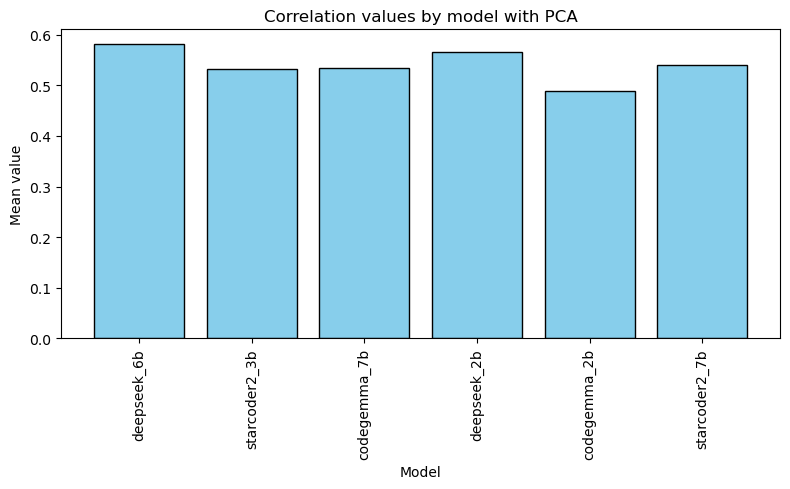

In [17]:
# RQ3 - how do the different models relate to ridge regression performance? Collect correlation values for each model

# Compute means
labels = list(model_performance_pca.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in model_performance_pca.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("Model")
plt.xticks(rotation=90)
plt.title("Correlation values by model with PCA")
plt.tight_layout()
plt.show()

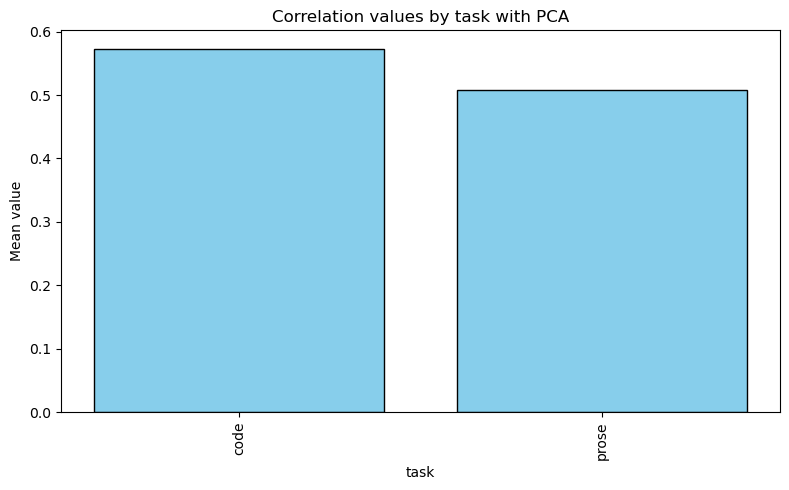

In [18]:
# RQ4 - how do the tasks compare to one another? Collect correlation values for the two tasks

# Compute means
labels = list(task_performance_pca.keys())
# labels = [f"{l} Exp: {demo_data.loc[participant_index(l), 'semesters_experience']}, GPA: {demo_data.loc[participant_index(l), 'GPA']}" for l in labels]
means = [np.mean(v) for v in task_performance_pca.values()]

# Plot
plt.figure(figsize=(8,5))
plt.bar(labels, means, color='skyblue', edgecolor='black')
plt.ylabel("Mean value")
plt.xlabel("task")
plt.xticks(rotation=90)
plt.title("Correlation values by task with PCA")
plt.tight_layout()
plt.show()

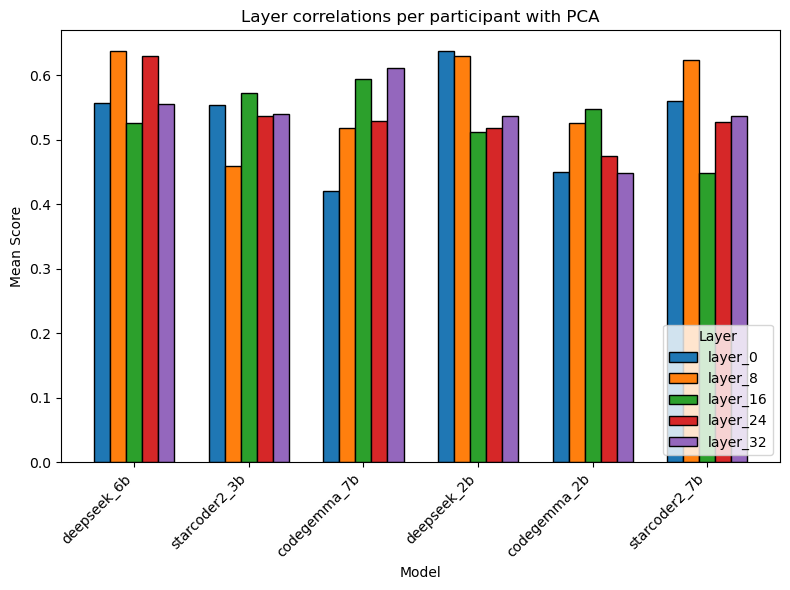

In [19]:
layer_performance = json.loads(json.dumps(layer_performance_pca))

models = list(layer_performance_pca.keys())
layers = list(next(iter(layer_performance_pca.values())).keys())  # assume all participants have same tasks

layers = sorted(
    next(iter(layer_performance_pca.values())).keys(),
    key=lambda x: int(x.split('_')[1])
)

# Compute means
# means = {p: [np.mean(data[p][t]) for t in tasks] for p in participants}
means = {}
for model, layerScores in layer_performance_pca.items():
    for layer,scores in layerScores.items():
        if model not in means.keys():
            means[model] = [np.mean(scores)]
        else:
            # print(model, layer, scores)
            means[model].append(np.mean(scores))
            
# means = {m: [layer_performance[m][l] for l in layers] for m in models}

# Plot grouped bars
x = np.arange(len(models))  # positions for participants
width = 0.35 / len(layers) * 2     # adjust width depending on number of tasks

plt.figure(figsize=(8,6))
for i, layer in enumerate(layers):
    plt.bar(x + i*width, [means[m][i] for m in models],
            width, label=layer, edgecolor='black')

plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.title("Layer correlations per participant with PCA")
plt.xticks(x + width*(len(layers)-1)/2, models, rotation=45, ha='right')
plt.legend(title="Layer", loc='lower right')
plt.tight_layout()
plt.show()

In [6]:
filename = "/storage1/fmri_model_data/ridge_regression_pca_models/111/deepseek_2b-layer_0-code-cosine_similarities.pkl"

with open(filename, 'rb') as f:
    cos = pickle.load(f)

In [9]:
test = cos.copy()
test.sort()